#次元削減

In [1]:
次元削減 -> なるべくデータの情報を失わないようにデータの次元数を減らすという教師なし学習の手法
複雑なデータを2次元平面にわかりやすく図示する時によく用いられる,次元を下げて可視化してわかりやすくする

特異値分解(SVD) -> 解釈しやすい,得られたデータを分析したい場合に用いる
UMAP -> 複雑な計算はあるがかなり綺麗な図を作れる,綺麗な2次元のデータを作りたい場合に用いる, データ多ければUMAPのほうが良い

SyntaxError: ignored

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/4-1_skill_level.csv",index_col=0)
#  人の名前を列名にしたいので,index_col=0にする
df

,コミュニケーション,リーダーシップ,プログラミング,ネットワーク知識,セキュリティ知識
A,7,6,9,10,8
B,2,2,4,3,5
C,7,5,6,5,7
D,7,6,10,9,9
E,9,9,3,4,6
F,6,6,9,9,8
G,3,2,5,6,4
H,10,9,9,8,10
I,5,4,8,5,7
J,2,2,4,3,2


#SVD

In [3]:
#ライブラリimport
from sklearn.decomposition import TruncatedSVD

In [4]:
#インスタンス化
model_svd = TruncatedSVD(n_components=2)
# n_components=2 - 次元数

In [5]:
# データを突っ込んで学習
vecs_list = model_svd.fit_transform(df)
# これで5次元だったものが2次元になる

vecs_list
#データが15個あって,各々2つ(２次元)ある,次元削減なのでデータ数が減る

array([[18.01133639, -2.08959984],
       [ 7.27762252, -1.34850332],
       [13.43360847,  0.88719484],
       [18.48263999, -2.2094704 ],
       [13.5780639 ,  6.1876989 ],
       [17.11594851, -2.12956552],
       [ 9.08409326, -2.55117285],
       [20.52943048,  1.85110185],
       [13.08955913, -1.59539868],
       [ 5.84600801, -1.13171928],
       [12.27621495, -2.53269306],
       [18.16236577,  3.51346277],
       [11.26994049, -0.99784624],
       [12.60578035, -1.82569588],
       [17.33721911,  2.48094994]])

In [6]:
# 0番目が並んだリストにしたい
X = vecs_list[:,0] #1つ目のデータ
Y = vecs_list[:,1] #2つ目のデータ

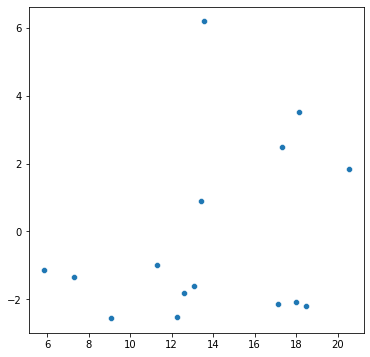

In [7]:
# 可視化
plt.figure(figsize=(6,6))
sns.scatterplot(x=X,y=Y)

# 二次元になったがどれが誰かわからないのでfor文で指定して名前を追加する

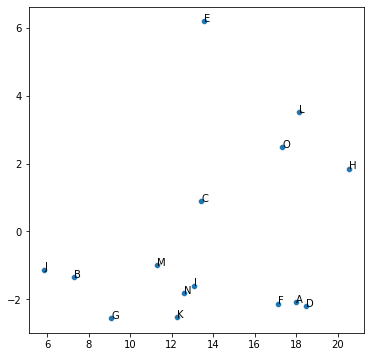

In [8]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=X,y=Y)

for i,(annot_x,annot_y) in enumerate(zip(X,Y)): #これで一気にplotされる
    plt.annotate(df.index[i],(annot_x,annot_y)) #df.index[i]=a,b,c,d,,,が入っている, annot_x,annot_y = 座標

# どういう２次元になったか(xとyの意味)は人間が考えなければいけない
# 一番大事なのは総合点(x軸はスキル能力),上下はヒューマンスキルは上、IT知識は下の分布

In [9]:
# y軸を確認する方法 -> model_svd.components_
model_svd.components_ #元データに対して2次元に圧縮している(縦で圧縮)

array([[ 0.43065824,  0.40038966,  0.4588284 ,  0.46472964,  0.47720484],
       [ 0.4623948 ,  0.61772725, -0.47003834, -0.42242911, -0.07226134]])

/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 12467 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 12511 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 12517 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 12491 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 12465 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 12540 missing from current font.
  font.set_

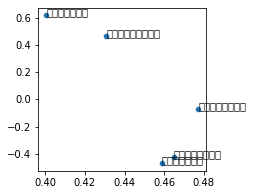

In [10]:
X_comp,Y_comp = model_svd.components_
plt.figure(figsize=(3,3))
sns.scatterplot(x=X_comp,y=Y_comp)
 
for i,(annot_x,annot_y) in enumerate(zip(X_comp,Y_comp)):
    plt.annotate(df.columns[i],(annot_x,annot_y))

# 上から(リーダーシップ,コミュニケーション,セキュリティ知識,ネットワーク知識,プログラミング)
# ヒューマンスキルが高い人は上に配置されて、IT知識が下の方に来る

In [11]:
# 寄与度 - 情報がどれくらい残っているのかわかる
model_svd.explained_variance_ratio_

# array([0.67907875, 0.247028]) -> 第1主成分は約68%,第2主成分は約25%ぐらいデータが残っているとみれる
# つまり90%ぐらいはデータが残っている,データが残っている(データが60~70くらい残っていたら良い)

array([0.67907875, 0.247028  ])

#UMAP

In [12]:
pip install umap-learn

In [13]:
# SVDとほぼ同じ
import umap.umap_ as umap
from scipy.sparse.csgraph import connected_components

In [14]:
#インスタンス化
model_umap = umap.UMAP(n_components=2,n_neighbors=6) #指定した方が良い引数(ここの値で結果がかなり変わる,一番良い値を調整して出す) -> n_neighbors = 数字 
# n_components=2 - 次元数

In [15]:
# データを突っ込んで学習
vecs_list = model_umap.fit_transform(df)
# これで5次元だったものが2次元になる

vecs_list
#データが15個あって,各々2つ(２次元)ある,次元削減なのでデータ数が減る

/usr/local/lib/python3.7/dist-packages/numba/np/ufunc/parallel.py:363: NumbaWarning: The TBB threading layer requires TBB version 2019.5 or later i.e., TBB_INTERFACE_VERSION >= 11005. Found TBB_INTERFACE_VERSION = 9107. The TBB threading layer is disabled.
  warnings.warn(problem)


array([[-1.4615242e+00,  4.5504994e+00],
       [ 1.5545255e+00,  2.6620247e+00],
       [-3.2678464e-01,  1.7616396e+00],
       [-1.5082879e+00,  4.9921136e+00],
       [-2.9548333e+00,  4.4241390e+00],
       [-1.8342844e+00,  4.2509360e+00],
       [ 1.5554230e+00,  1.9370836e+00],
       [-2.2390807e+00,  5.2482085e+00],
       [ 5.3379632e-04,  2.1670768e+00],
       [ 1.9311649e+00,  2.3635607e+00],
       [ 8.7373519e-01,  2.0410526e+00],
       [-2.8795068e+00,  5.0206881e+00],
       [ 9.8728192e-01,  1.4465705e+00],
       [ 3.6271128e-01,  1.6040496e+00],
       [-2.5486660e+00,  4.6162229e+00]], dtype=float32)

In [16]:
# 0番目が並んだリストにしたい
X = vecs_list[:,0] #1つ目のデータ
Y = vecs_list[:,1] #2つ目のデータ

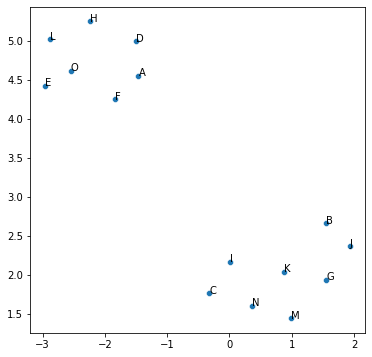

In [17]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=X,y=Y)

for i,(annot_x,annot_y) in enumerate(zip(X,Y)): 
    plt.annotate(df.index[i],(annot_x,annot_y)) 

# データ数が少ないとあまり良い結果が出ない

In [18]:
# これだけ使えれば問題ない,データ多ければUMAPのほうが良い